In [1]:
import uproot
import pandas as pd
import numpy as np
import json
from scipy.optimize import curve_fit, minimize
from scipy.stats import argus
from scipy.integrate import quad
from numpy import  log, sqrt, exp, pi, e
import multiprocessing
import os
from numba import njit
from source import *
import matplotlib.gridspec as gridspec
plt.rcParams['text.usetex'] = True


/tmp/ipykernel_121138/1103364884.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
def errorhist(data, bins=10, fmt='.', color='dimgrey', err_func = np.sqrt, axs = plt, label = None):
        counts, bin_edges = np.histogram(data, bins=bins)
        bin_centers = bin_edges[:-1] + (bin_edges[1] - bin_edges[0]) / 2
        axs.errorbar(bin_centers, counts, yerr=err_func(counts), fmt=fmt, color=color, label = label)
        return counts, bin_centers

<ValueView x0=7.999815111971488 x1=0.9333290343827857 x2=1.0651351797304112 x3=2.025642517007715 x4=0.30291505715188677>
7.999815111971488 0.9333290343827857 1.0651351797304112 2.025642517007715 0.30291505715188677


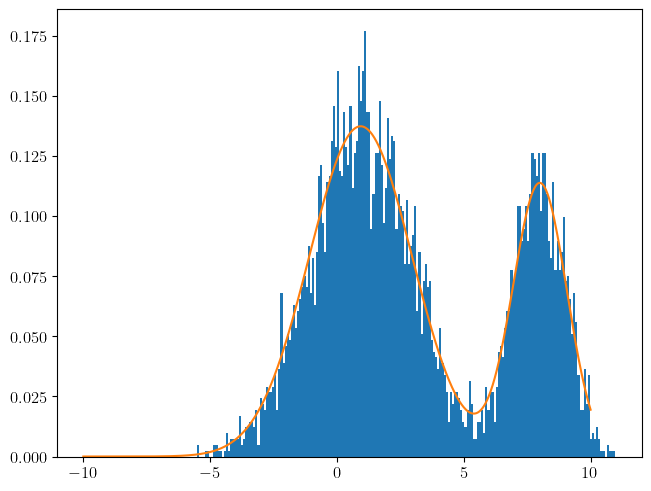

In [3]:
N = 5000
tau = 0.3
x = np.concatenate((np.random.normal(8, 1, int(N*tau)), np.random.normal(1, 2, int(N*(1-tau)))))
plt.hist(x, density=True, bins=200)
counts, bin_edges = np.histogram(x, bins=15)
bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
f = lambda x, mu1, mu2, s1, s2, tau: gaussian(x, mu1, s1)*tau + gaussian(x, mu2, s2)*(1-tau)
args, _ = max_bin_lik(f, bin_centers, counts, (8, 2, 1, 1, 0.5))
xx = np.linspace(-10, 10, 1000)
print(*args)
plt.plot(xx, f(xx, *args))

In [4]:
dataframes = []
for filename in os.listdir("chen_sv"):
    if filename.endswith('.root'):
        filepath = os.path.join("chen_sv", filename)
        with uproot.open(filepath) as file:
            tupl2 = file['h1']
            tkeys = tupl2.keys()
            print(f"Keys in {filename}: {tkeys}")
            inc = tupl2.arrays(library='pd')
            inc['source_file'] = filename
            dataframes.append(inc)

inc = pd.concat(dataframes, ignore_index=True)

Keys in 0.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 1.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 2.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 3.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 4.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 5.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 6.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 7.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 8.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']
Keys in 9.root: ['ecm', 'rm', 'dsm', 'dm', 'dsp', 'dp', 'ntr', 'chxc', 'chac']


In [5]:
decay_mod_taging = ["$X_c \\to D^0 p$", "$X_c \\to D^+ p \\pi^- $", "$X_c \\to D^{*0} p$", "$X_c \\to D^{*+} p \\pi^-$", "$X_c \\to \\Lambda_c^-$", "$X_c \\to \\Lambda_c^- \\pi^- \\pi^+$"]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_121138/4202766850.py:24: UserWarning: The f

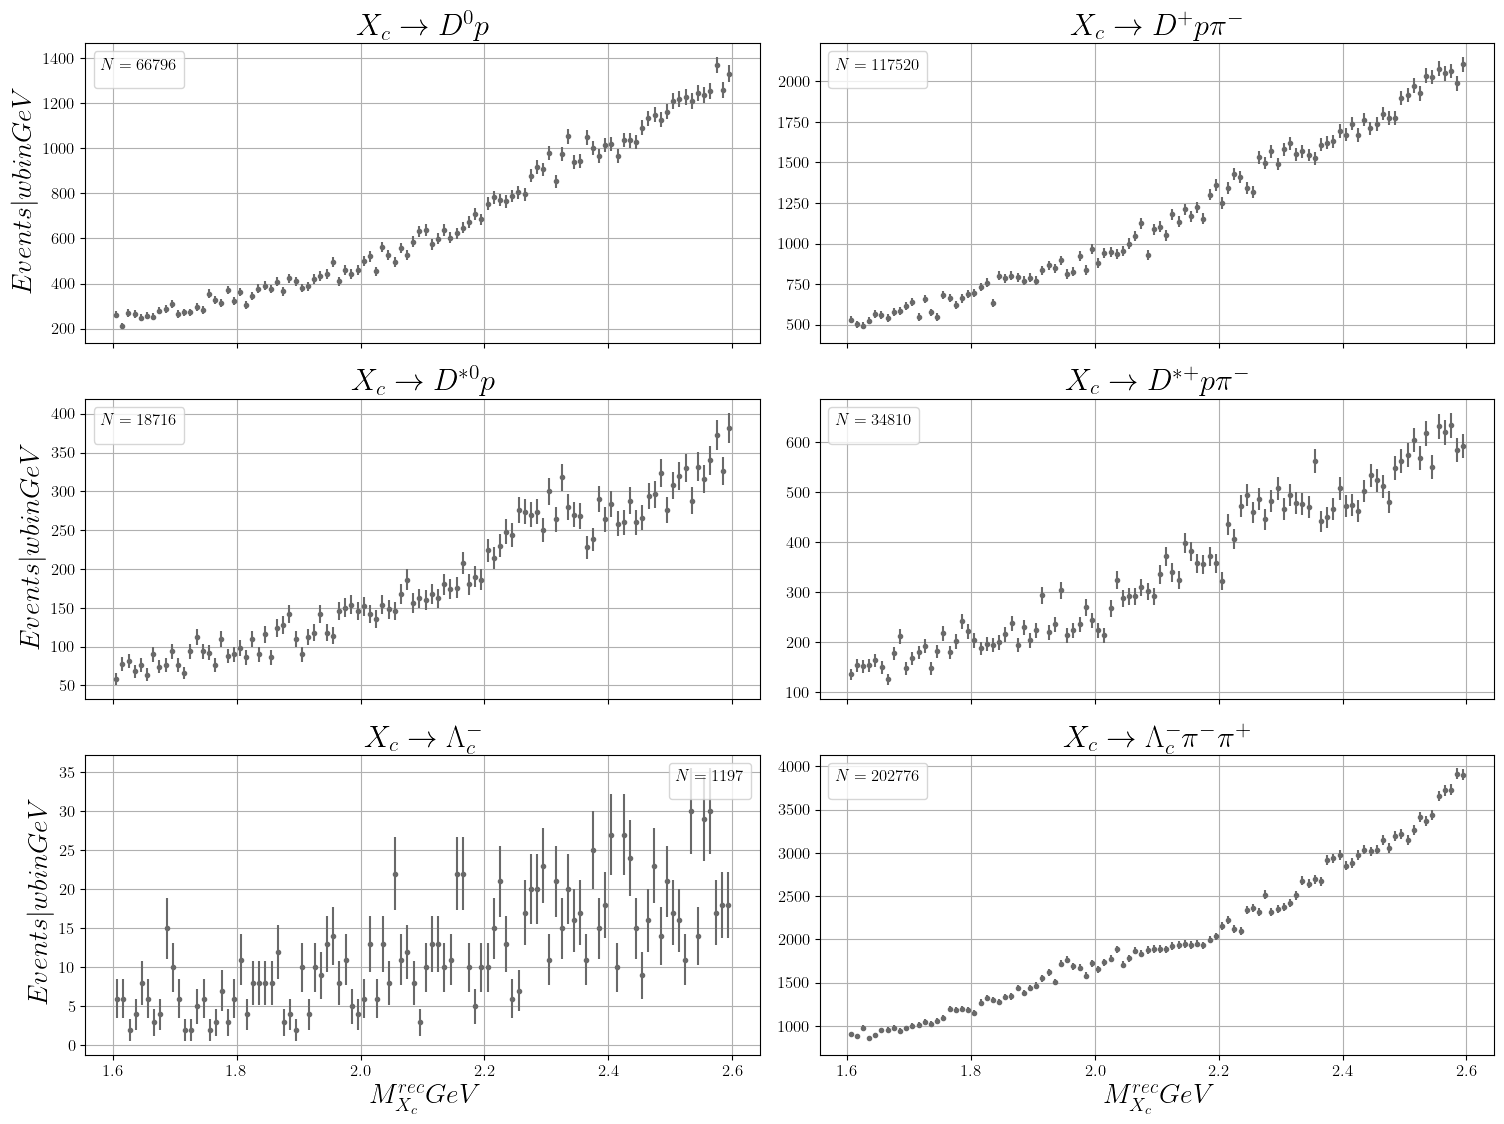

In [6]:
wbin = 0.01
a = 1.6
b = 2.6

fig, axs = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
for ind, i in enumerate(range(1, 7)):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.chxc == i) & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - Ds_D_dif) < 0.003)) | 
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015)) | (inc.chxc > 4) )]
    N = dat.shape[0]
    
    # Make sure 'errorhist' is defined or use plt.hist as fallback
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), axs=axs[ind//2, ind%2])
    
    axs[ind//2, ind%2].grid()
    axs[ind//2, ind%2].set_title(decay_mod_taging[i-1])
    axs[ind//2, ind%2].legend(title=f"$N = {N}$")
    if (ind%2 == 0):
        axs[ind//2, ind%2].set_ylabel('$Events | {wbin} GeV$')
    if (ind >= 4):
        axs[ind//2, ind%2].set_xlabel('$M_{X_c}^{rec}GeV$')


plt.tight_layout(rect=[0.05, 0.05, 1, 1]) 
plt.show()


In [7]:
a = 1.6
b = 2.6
continuum_lam = njit(lambda x, A1, lam, mu, sig1, c0, c1, c2, c3, c4: A1*exp_dis(x - mu, lam, a - mu, b - mu) + (1-A1)*gaussian(x, 2.65, sig1) + c0*eval_chebyt(0, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c1*eval_chebyt(1, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c2*eval_chebyt(2, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c3*eval_chebyt(3, x - Lamc_m, a - Lamc_m, b - Lamc_m) + c4*eval_chebyt(4, x - Lamc_m, a - Lamc_m, b - Lamc_m)) 
f_lam = lambda x, A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4: A*gaussian(x, Lamc_m, sig) + (1-A)*continuum_lam(x, A1, lam, mu, sig1, c0, c1, c2, c3, c4)

<ValueView x0=0.03239260760850395 x1=0.9189989280403383 x2=1.5351468575593856 x3=0.9972912415249842 x4=0.07127876591947045 x5=0.15707108141827014 x6=-0.0017426545141078428 x7=-0.003924763654373217 x8=0.0037777847422543163 x9=-0.0009548798712761923 x10=0.00046865893674103657>
3.3884128166292413
<ValueView x0=0.02727524752288816 x1=0.979001356549187 x2=1.4612327057335888 x3=1.000242687486813 x4=0.07543131595278663 x5=0.15913863188386276 x6=-9.942563715906183e-06 x7=0.004108158768639611 x8=0.012096467035122054 x9=0.001246119241575928 x10=-0.000296025895506067>
2.9908458187659455
<ValueView x0=0.03208164604206283 x1=0.9799931008304017 x2=1.5173193467764723 x3=-1.4744009458661334 x4=0.059221943714975724 x5=0.19998362757259003 x6=-0.018446580737064164 x7=-0.0029517852640942067 x8=0.009320126126365156 x9=-0.0006153938116361295 x10=0.0004862455694921008>
1.6092625447409918
<ValueView x0=0.03258406253514447 x1=0.9823419170355258 x2=1.4753117303164696 x3=0.9827749593627477 x4=0.05926936350785128

/tmp/ipykernel_121138/666593263.py:49: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


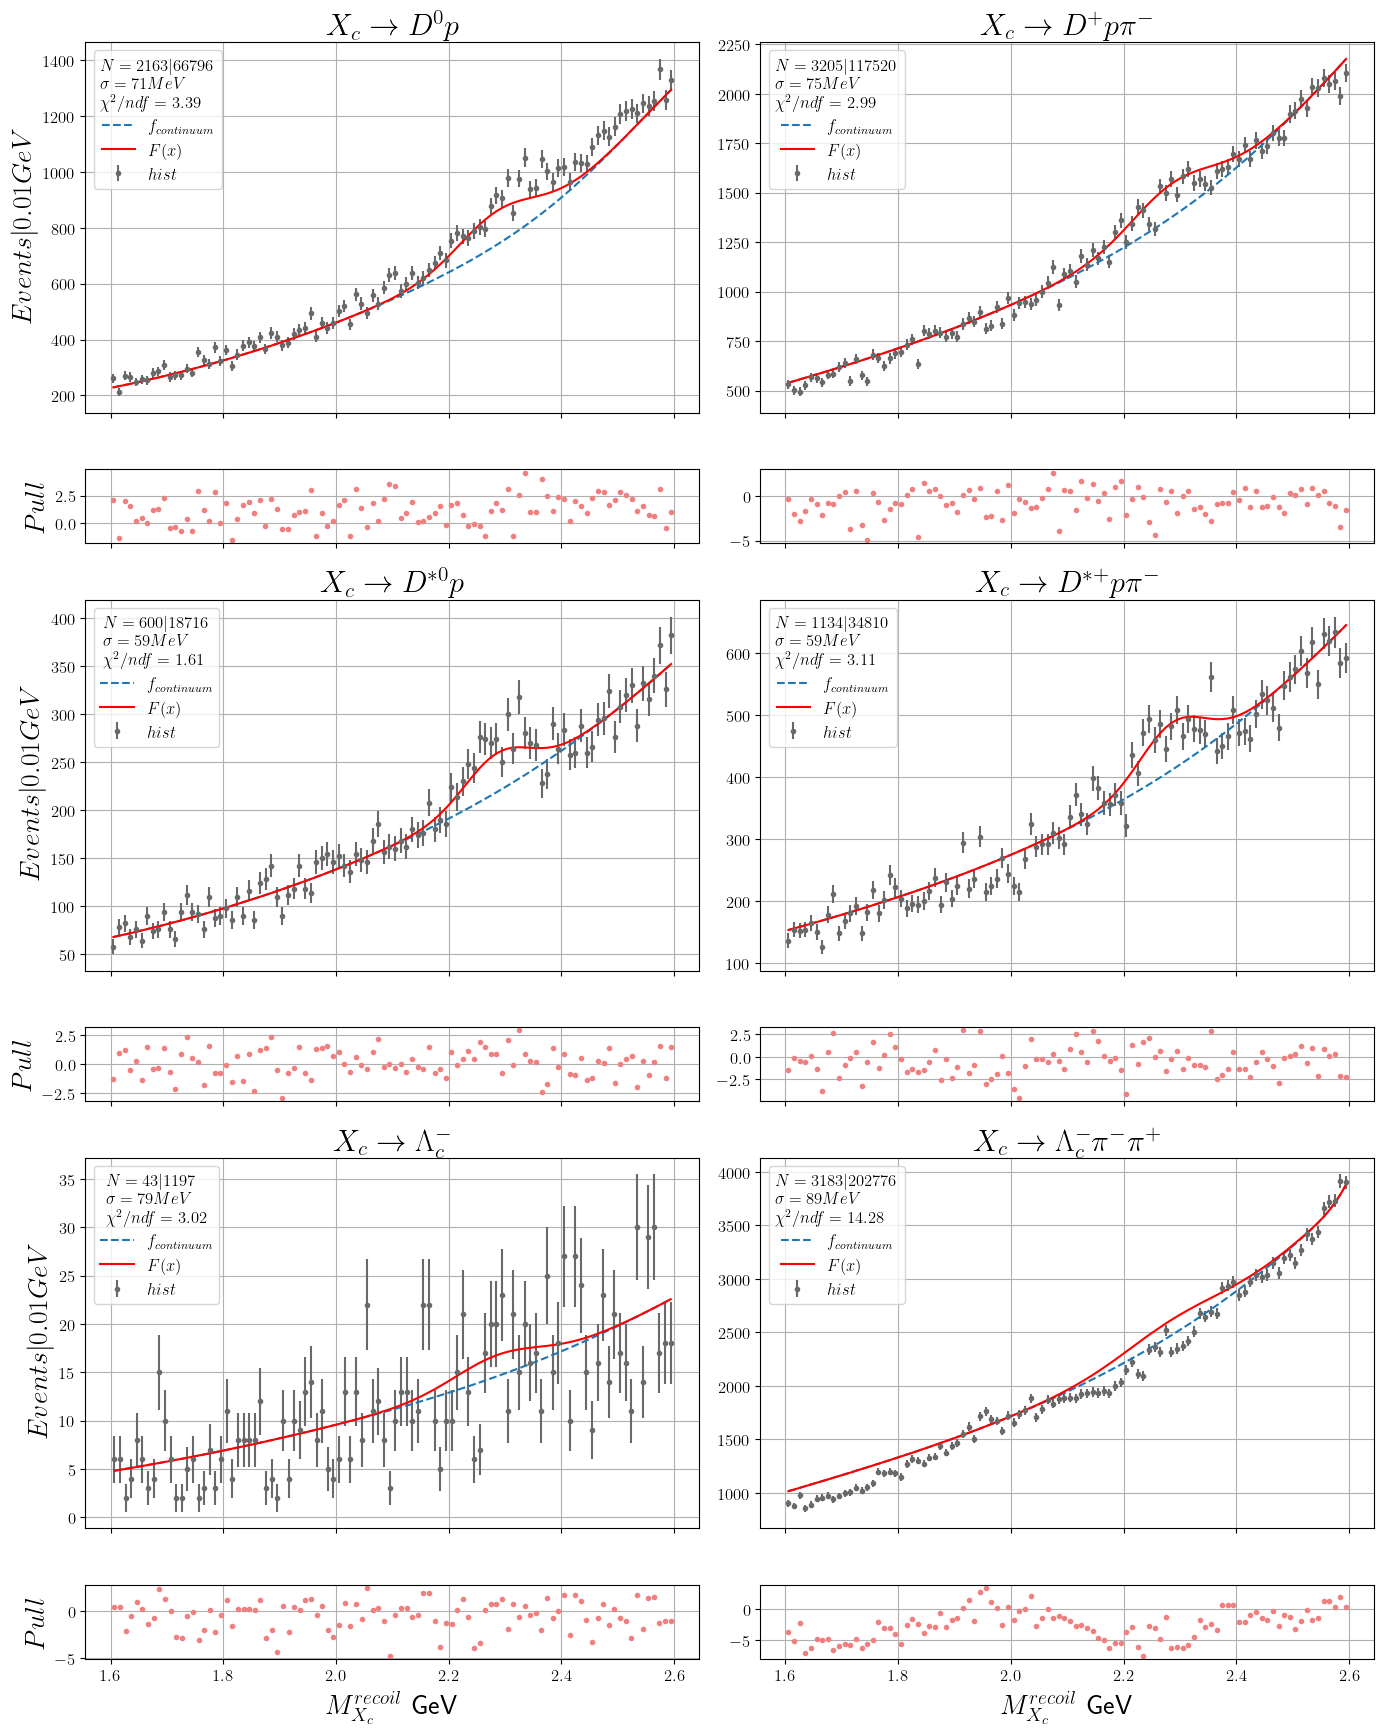

In [15]:
wbin = 0.01

fig, axs = plt.subplots(6, 2, figsize=(14, 14*2/1.6), gridspec_kw={'height_ratios': [1, 0.2]*3}, sharex=True)

for ind, i in enumerate(range(1, 7)):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc == i) & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - 0.142014) < 0.003)) |
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015))  | (inc.chxc > 4))]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="$hist$", axs=axs[ind//2 * 2, ind%2 ])      
    N = dat.shape[0]

    args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)
    if ind == 6:
        args = (0, 1, 1.5, 0, 0, 0.15, -1e-5, 0, 0.004, 0.001, 0)
        
    bounds = [(0, 1), (0, 1), (0, 10), (-5, 5), (0.0001, 0.2), (0.0001, 0.2), (-100, 100), (-50, 50), (-50, 50), (-10, 10), (-10, 10)]

    if i == 6:
        bounds = [(-1, 1), (0, 1), (0, 10), (-5, 5), (0.0001, 0.2), (0.0001, 0.2), (-100, 100), (-50, 50), (-50, 50), (-10, 10), (-10, 10)]


    ax_main = axs[ind//2 * 2, ind%2] 
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds=bounds)
    norm = N * wbin
    expected = f_lam(bin_centers, *args)
    chi2 = np.sum(((expected*norm - counts)**2) / (counts))
    title = decay_mod_taging[i-1]
    A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4 = args
    ax_main.plot(bin_centers, (1-A)*continuum_lam(bin_centers, A1, lam, mu, sig1, c0, c1, c2, c3, c4)* norm, label='$f_{continuum}$', linestyle='--')    
    print(chi2/(int((b-a)/wbin)-len(args)))
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label=f"$F(x)$", color = 'red')
    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$Events | {wbin} GeV$')
    ax_main.grid()

    ax_main.legend(title=f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$ \n $\\chi^2/ndf = {chi2/(int((b-a)/wbin)-len(args)):.2f}$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    if ind >= 4:
        ax_resid.set_xlabel('$M^{recoil}_{X_c}$  GeV')
    if ind%2 == 0:
        ax_resid.set_ylabel('$Pull$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()

plt.tight_layout()
plt.show()


<ValueView x0=0.033175892472383686 x1=0.9804470264003204 x2=1.517043221537826 x3=1.0062516403631478 x4=0.047023031351270665 x5=0.19915279054203375 x6=-0.02117796828778452 x7=-0.002502609094143059 x8=0.009603304085113366 x9=-0.000529496900923499 x10=0.0004878447988883876>
<ValueView x0=0.03789051995976904 x1=0.9738296688073723 x2=1.5281691520118474 x3=1.0131982532281085 x4=0.05882425065100465 x5=0.04913794799642747 x6=-0.0009883115777208846 x7=-0.0037737088333205334 x8=0.006672523344837061 x9=-0.0007660489521595956 x10=0.0004702085109578296>


/tmp/ipykernel_121138/3770072294.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


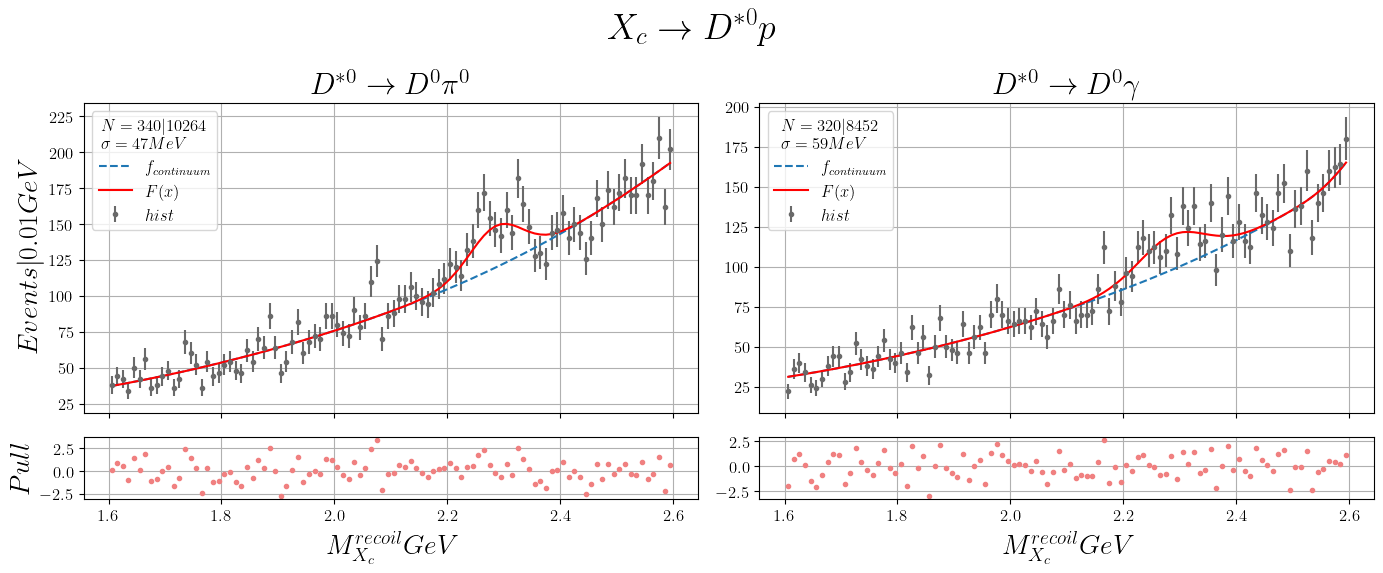

In [14]:
wbin = 0.01
decay_mod_ach = ["$D^{*0} \\to D^0 \\pi^0$","$D^{*0} \\to D^0 \\gamma$"]

fig, axs = plt.subplots(2, 2, figsize=(14, 14*2/1.6/3), gridspec_kw={'height_ratios': [1, 0.2]}, sharex=True)
fig.suptitle("$X_c \\to D^{*0} p$", fontsize=26)  
for ind, i in enumerate(range(1, 3)):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc == 3) & (inc.chac == i)  & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - 0.142014) < 0.003)) |
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015))  | (inc.chxc > 4))]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="$hist$", axs=axs[ind//2 * 2, ind%2 ])      
    N = dat.shape[0]

    args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)
    if ind == 6:
        args = (0, 0.98, 1.5, 0, 0, 0.15, -1e-5, 0, 0.004, 0.001, 0)
        
    bounds = [(0, 1), (0, 1), (-2, 3), (-1, 4), (0.0001, 0.2), (0.0001, 0.2), (-5, 5), (-5, 5), (-5, 5), (-5, 5), (-5, 5)]

    ax_main = axs[ind//2 * 2, ind%2] 
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds=bounds)
    title = decay_mod_ach[i-1]
    norm = N * wbin
    A, A1, lam, mu, sig, sig1, c0, c1, c2, c3, c4 = args
    ax_main.plot(bin_centers, (1-A)*continuum_lam(bin_centers, A1, lam, mu, sig1, c0, c1, c2, c3, c4)* norm, label='$f_{continuum}$', linestyle='--')    
#    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label=f"$F(x)$", color = 'red')
    ax_main.legend(title=f"$N = {N}$")
    ax_main.set_title(title)
    if ind%2 == 0:
        ax_main.set_ylabel(f'$Events | {wbin} GeV$')
    ax_main.grid()

    ax_main.legend(title=f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind//2 * 2 + 1, ind%2 ]
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('$M^{recoil}_{X_c}  GeV$')
    if ind%2 == 0:
        ax_resid.set_ylabel('$Pull$')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()

plt.tight_layout()
plt.show()


<ValueView x0=0.030911934408670887 x1=0.9774662478434823 x2=1.5141121314541972 x3=1.0011875624213336 x4=0.0457212346475646 x5=0.1977015930714861 x6=-0.014474616378407731 x7=-0.0025456018116612874 x8=0.002322803269040951 x9=-0.0005463504507088911 x10=0.00031549893000852114>
<ValueView x0=0.03098422327654426 x1=0.9751348343851826 x2=1.4905541986749302 x3=0.9922187791105134 x4=0.06182688881211095 x5=0.1954263185568383 x6=0.0038923384747182248 x7=0.001034435416236696 x8=0.005253091828086899 x9=0.0002823268843055384 x10=-2.5809396347457858e-05>


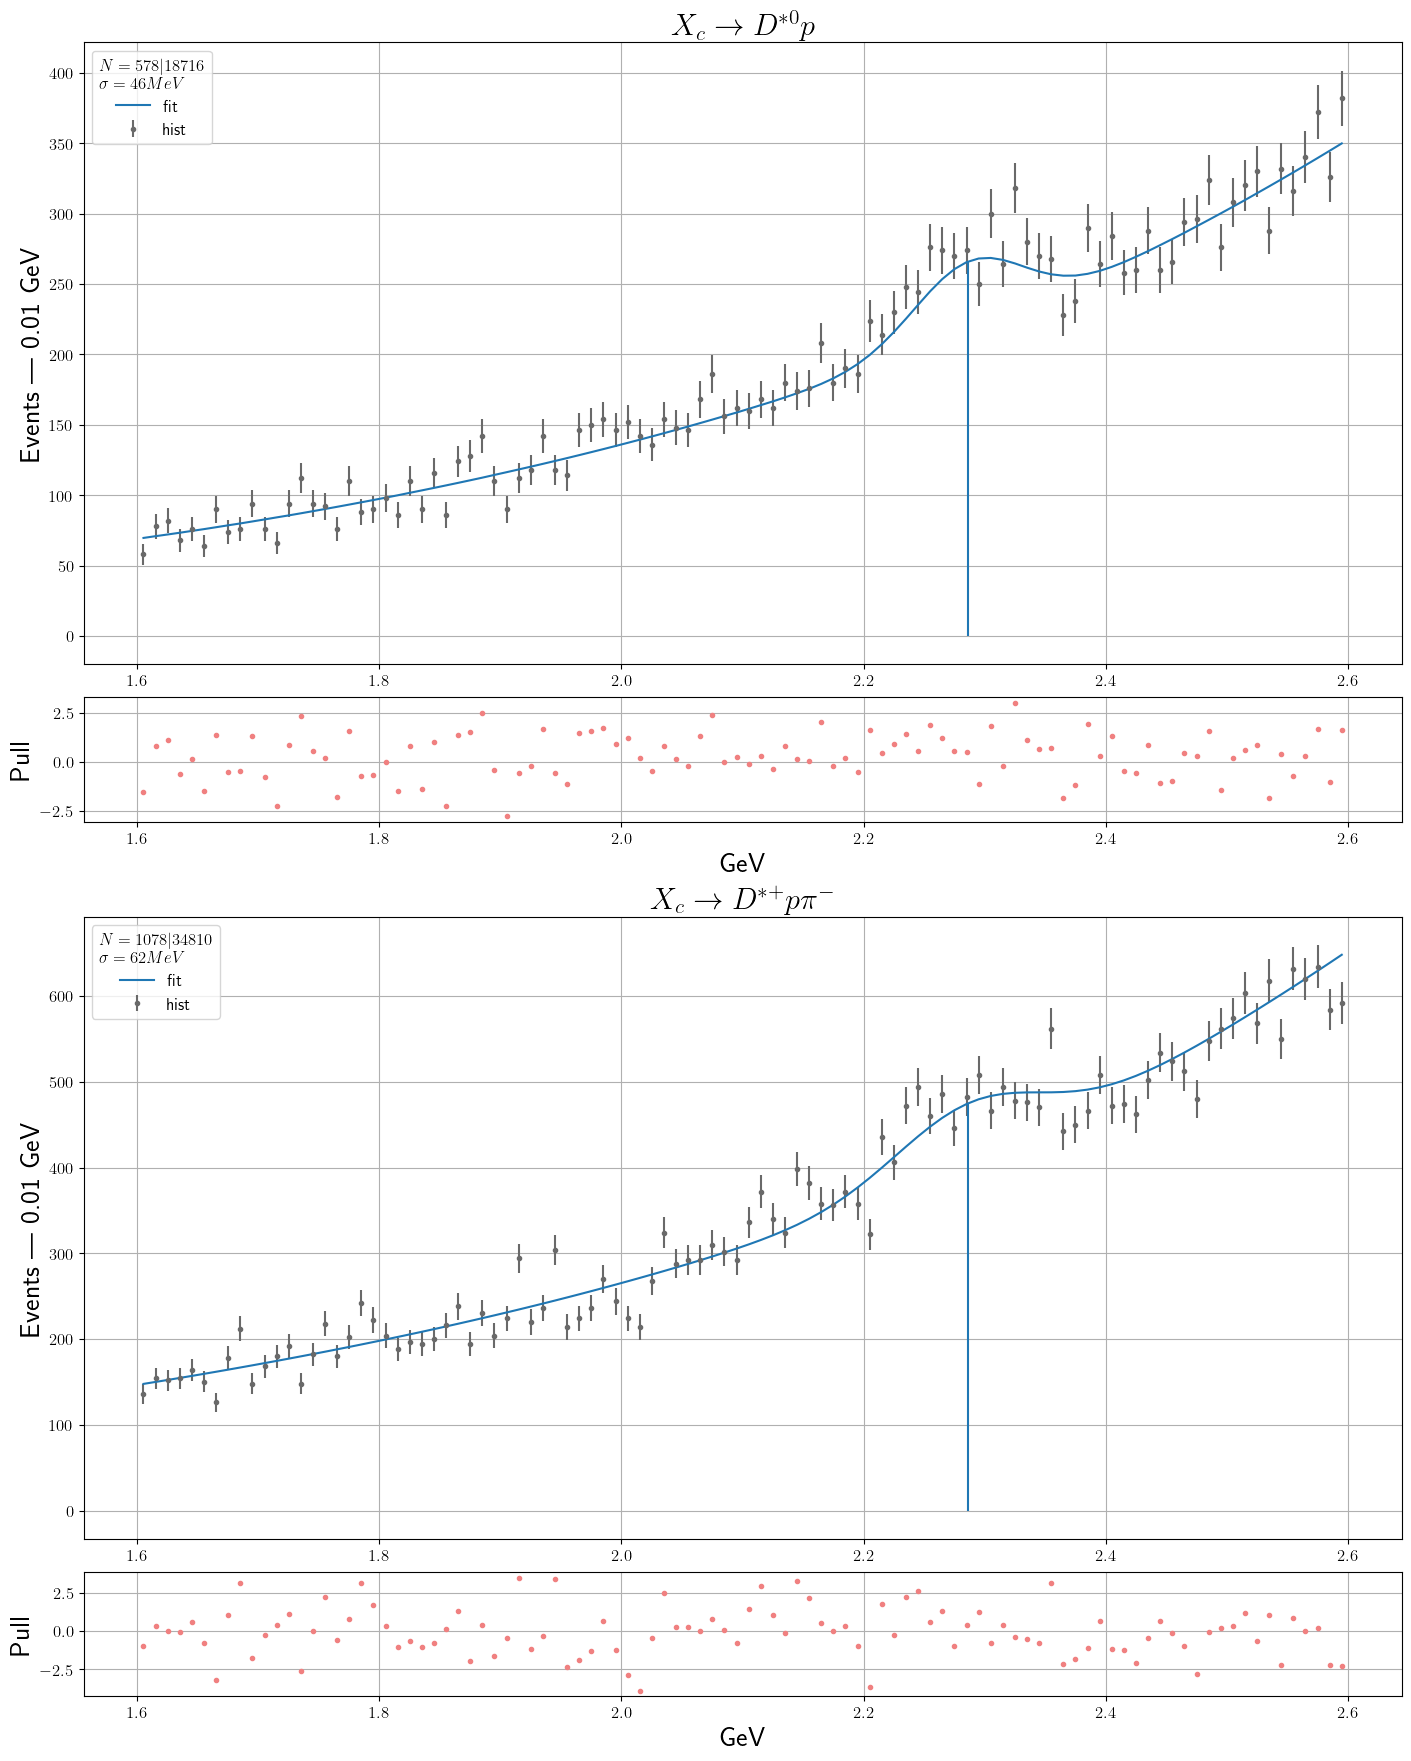

In [10]:
wbin = 0.01

fig, axs = plt.subplots(4, 1, figsize=(14, 14*2/1.6), gridspec_kw={'height_ratios': [1, 0.2, 1, 0.2]})

for ind, i in enumerate(range(3, 5)):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc == i) & (
              ((inc.chxc >= 3) & (np.abs(inc.dsm - inc.dm - 0.142014) < 0.003)) |
              ((inc.chxc <= 2) & (np.abs(inc.dm - D_0_m) < 0.015)))]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="hist", axs=axs[ind*2])      
    N = dat.shape[0]
    if ind == 0:
        args = (1.5e-02, 0.99, 1.5, 1, 0.05, 0.15, -4.5e-05, 0, 0, 0, 0)
    else:
        args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)
    bounds = [(0, 1), (0, 1), (0, 3), (-1, 4), (0.0001, 0.1), (0.0001, 0.2), (-1, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-0.5, 0.5), (-1e-3, 1e-3)]

    ax_main=axs[ind*2]
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds = bounds)
    title = decay_mod_taging[i-1]
    norm = N * wbin
    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label = f"fit")
    ax_main.legend(title=f"$N = {N}$")
    ax_main.set_title(title)
    ax_main.set_ylabel(f'Events | {wbin} GeV')
    ax_main.grid()

    ax_main.legend(title = f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind*2+1] 
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('GeV')
    ax_resid.set_ylabel('Pull')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
    
plt.show()


<ValueView x0=0.03630202805940329 x1=0.9844990293942069 x2=1.4885749766659284 x3=0.9982576413455034 x4=0.07726796609947265 x5=0.1941589668347402 x6=-1.0683081477377151e-05 x7=0.0003753194196774789 x8=0.025053520516343932 x9=7.635070788478711e-05 x10=0.0005826881755760255>
<ValueView x0=0.019495746846354686 x1=0.9614557500437214 x2=1.4744403488983713 x3=1.1120068118085802 x4=0.08339673373865233 x5=0.047276372239056334 x6=0.009436781876753108 x7=0.003283807343593617 x8=0.01900319684794315 x9=0.001099370688243812 x10=-0.000172712186959165>


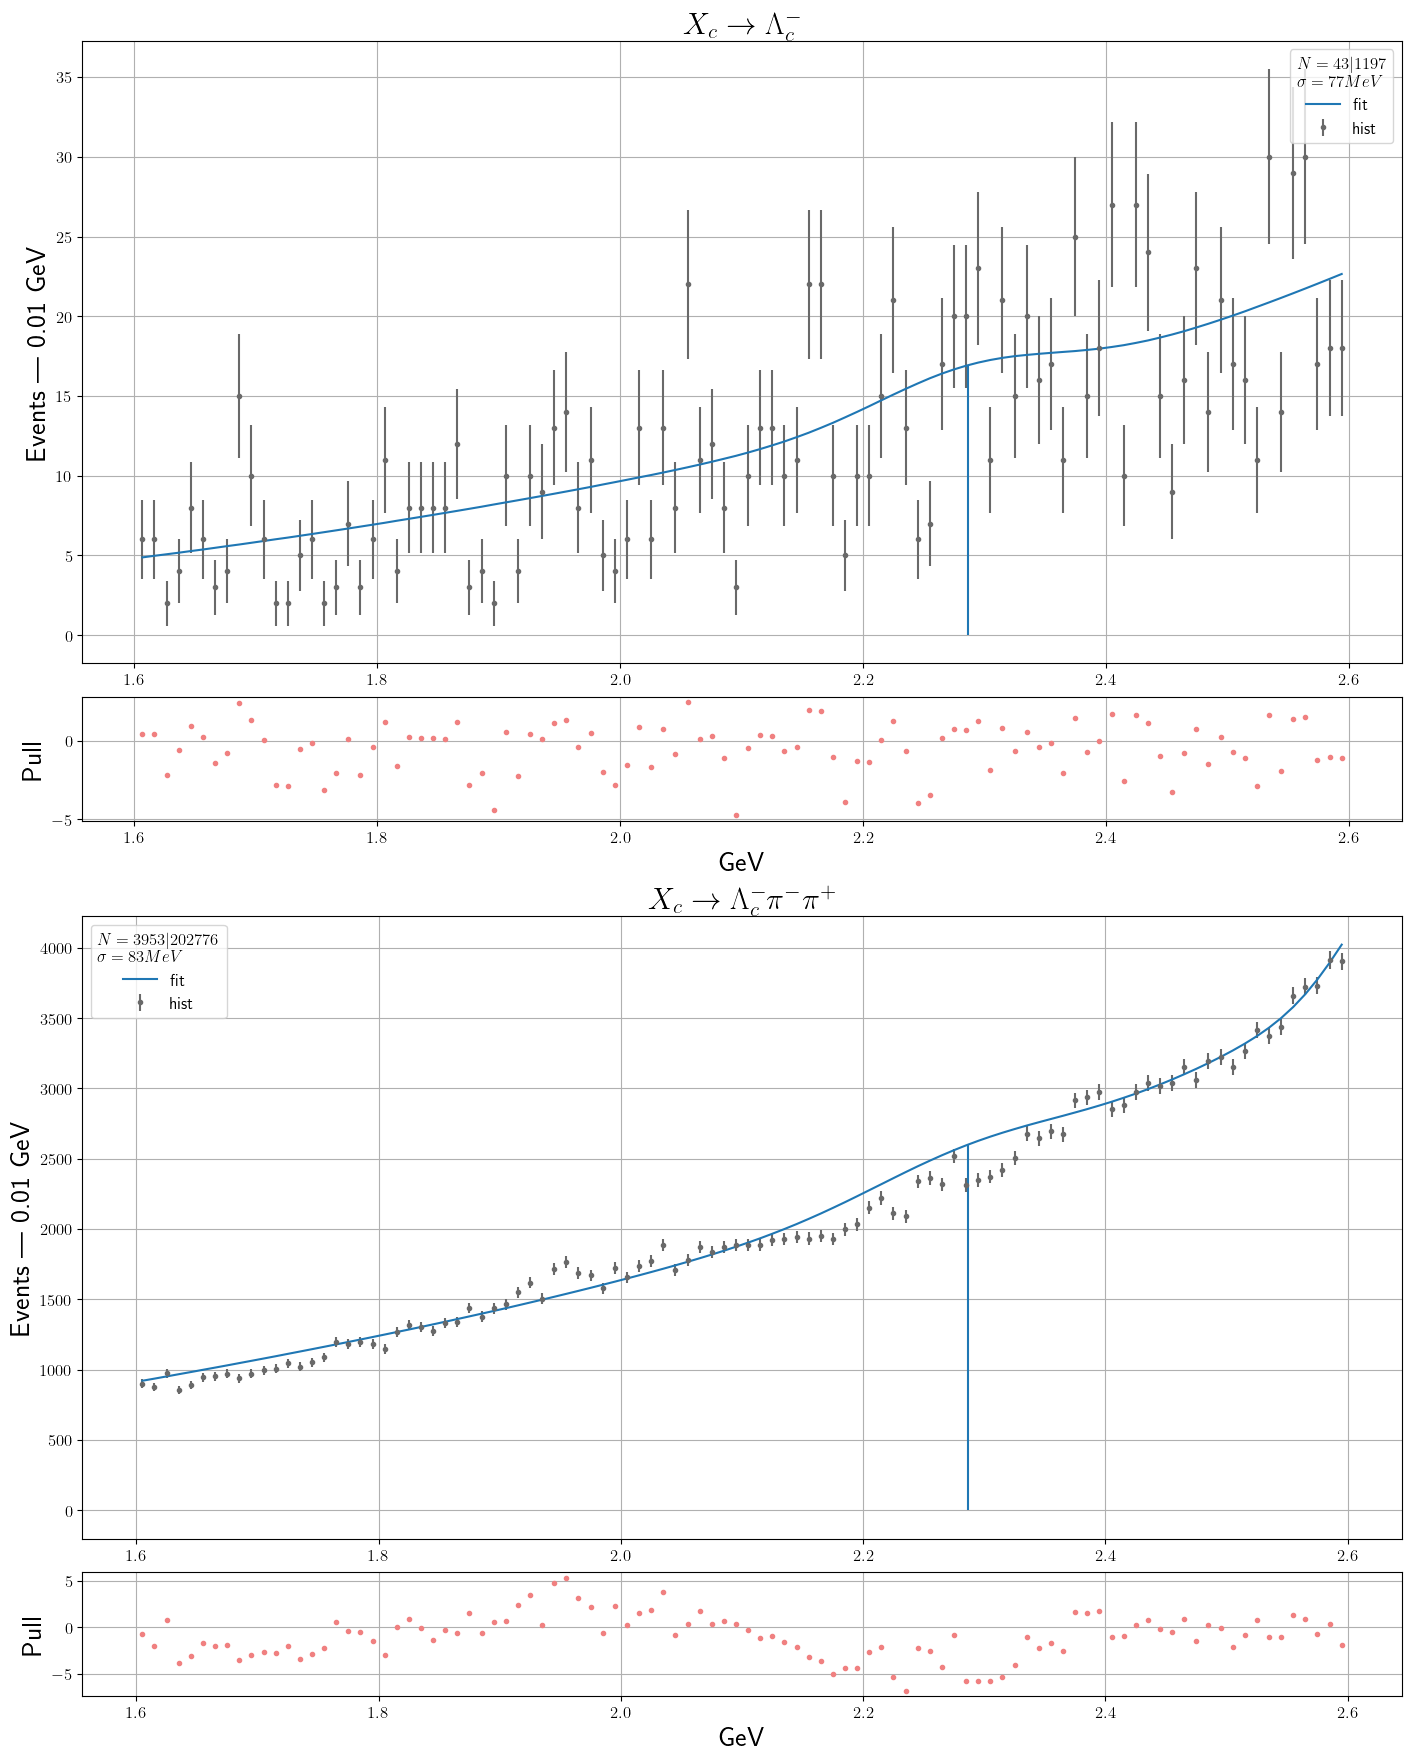

In [11]:
wbin = 0.01

fig, axs = plt.subplots(4, 1, figsize=(14, 14*2/1.6), gridspec_kw={'height_ratios': [1, 0.2, 1, 0.2]})

for ind, i in enumerate([5,6]):
    dat = inc[(inc.rm < b) & (inc.rm > a) & (inc.ntr <= 3) & (inc.chxc == i)]    
    counts, bin_centers = errorhist(dat.rm, bins=int((b-a)/wbin), color='dimgrey', label="hist", axs=axs[ind*2])      
    N = dat.shape[0]
    args = (0.03, 0.97, 1.5, 1, 0.07, 0.15, -1e-5, 0, 0, 0, 0)
    bounds = [(0, 1), (0, 1), (0, 3), (-1, 4), (0.01, 0.1), (0.01, 0.2), (-0.2, 0.2), (-0.2, 0.2), (-0.2, 0.2), (-0.2, 0.2), (-1e-3, 1e-3)]

    ax_main=axs[ind*2]
    args, _ = max_bin_lik(f_lam, bin_centers, counts, args, bounds = bounds)
    title = decay_mod_taging[i-1]
    norm = N * wbin
    ax_main.vlines(Lamc_m, f_lam(Lamc_m, *args)*norm, 0)
    ax_main.plot(bin_centers, f_lam(bin_centers, *args)*norm, label = f"fit")
    ax_main.legend(title=f"$N = {N}$")
    ax_main.set_title(title)
    ax_main.set_ylabel(f'Events | {wbin} GeV')
    ax_main.grid()

    ax_main.legend(title = f"$N = {int(args[0]*N)} | {N}$ \n $\\sigma = {1000*args[4]:.0f} MeV$")

    residuals = counts - f_lam(bin_centers, *args) * norm
    ax_resid = axs[ind*2+1]  # Residuals plot in right column
    ax_resid.plot(bin_centers, residuals / np.sqrt(counts), '.', color='lightcoral')
    ax_resid.set_xlabel('GeV')
    ax_resid.set_ylabel('Pull')
    ax_resid.set_xlim(ax_main.get_xlim()) 
    ax_resid.grid()
    
plt.show()
